In [2]:

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

plt.rcParams.update({

    "figure.figsize": (20, 10),
    "figure.dpi": 110,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "grid.alpha": 1

})

# Regularization



### Ridge

In [3]:
'''
In case of ridge reg what we do is that we add the square of l2 norm of the weights times some alpha 
in the loss fxn and as the algorithm tends to decrease the loss , the hypothesis tends to go towards a constant value
and that constant value is generally the data's mean 
'''

"\nIn case of ridge reg what we do is that we add the square of l2 norm of the weights times some alpha \nin the loss fxn and as the algorithm tends to decrease the loss , the hypothesis tends to go towards a constant value\nand that constant value is generally the data's mean \n"

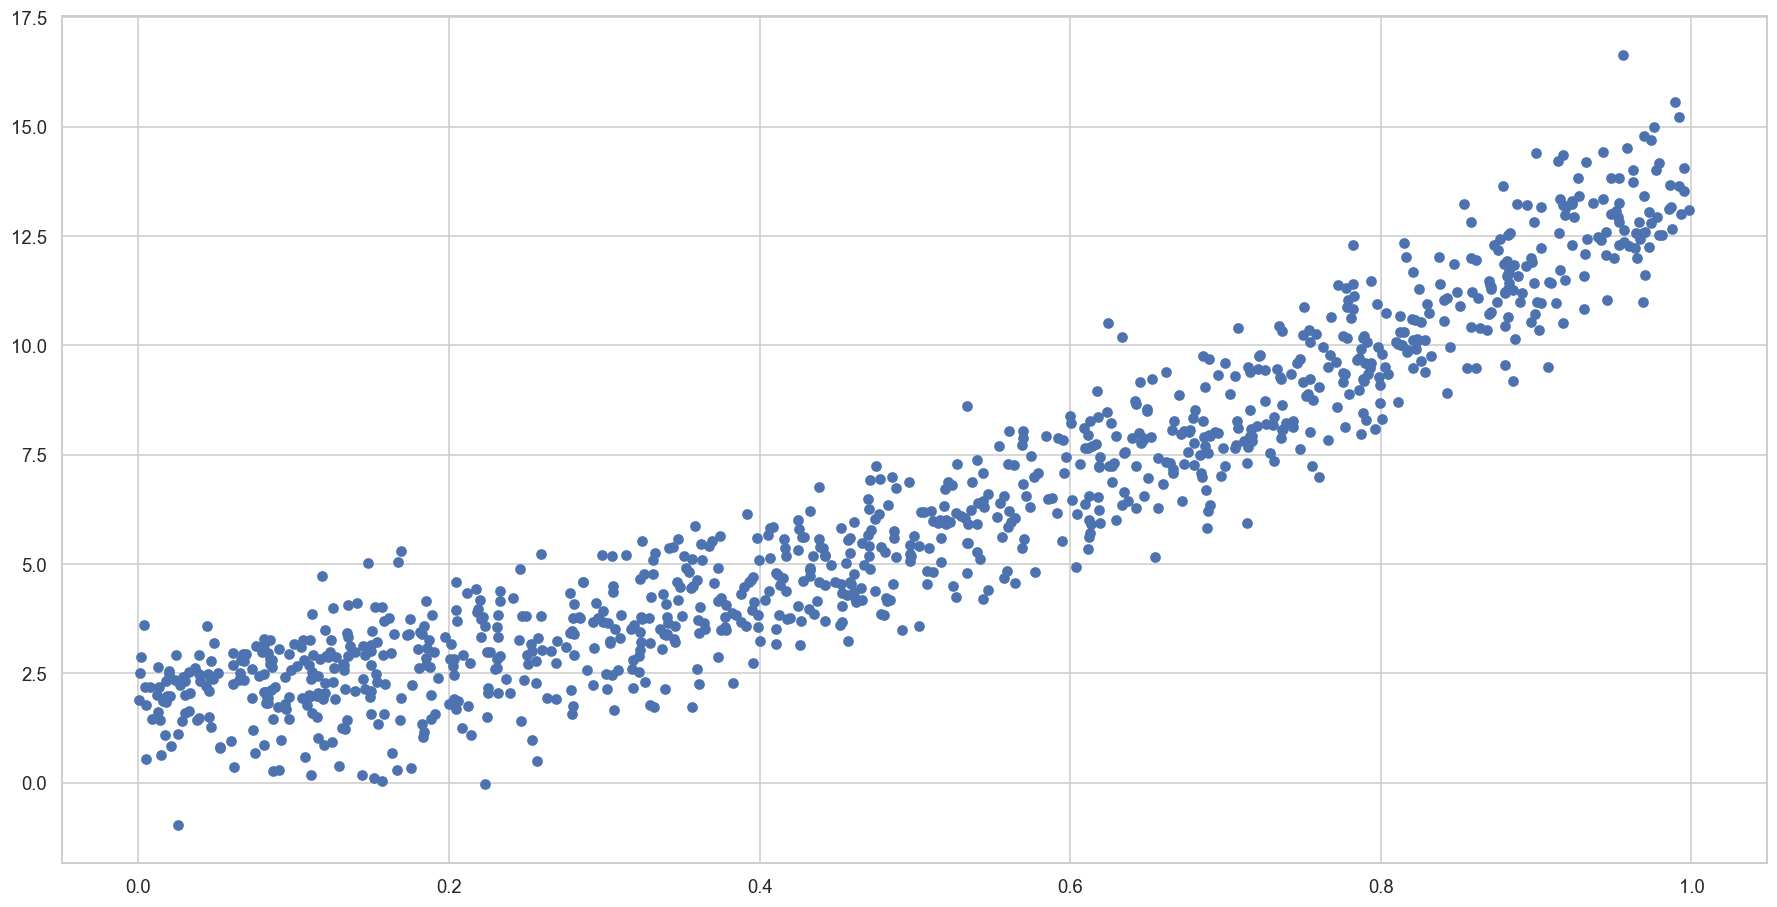

In [4]:
m = 1000
X = np.random.rand(m , 1)
y = 10* X**2 +2 * X + 2 + np.random.randn(m , 1)
plt.scatter(X , y)

In [ ]:
from sklearn.linear_model import Ridge 
from sklearn.preprocessing import PolynomialFeatures
ridge_reg = Ridge( alpha = 1 , solver = "cholesky")    # closed form solution of sickit learn

ridge_reg.fit(X , y)
ridge_reg.predict([[1.5]])



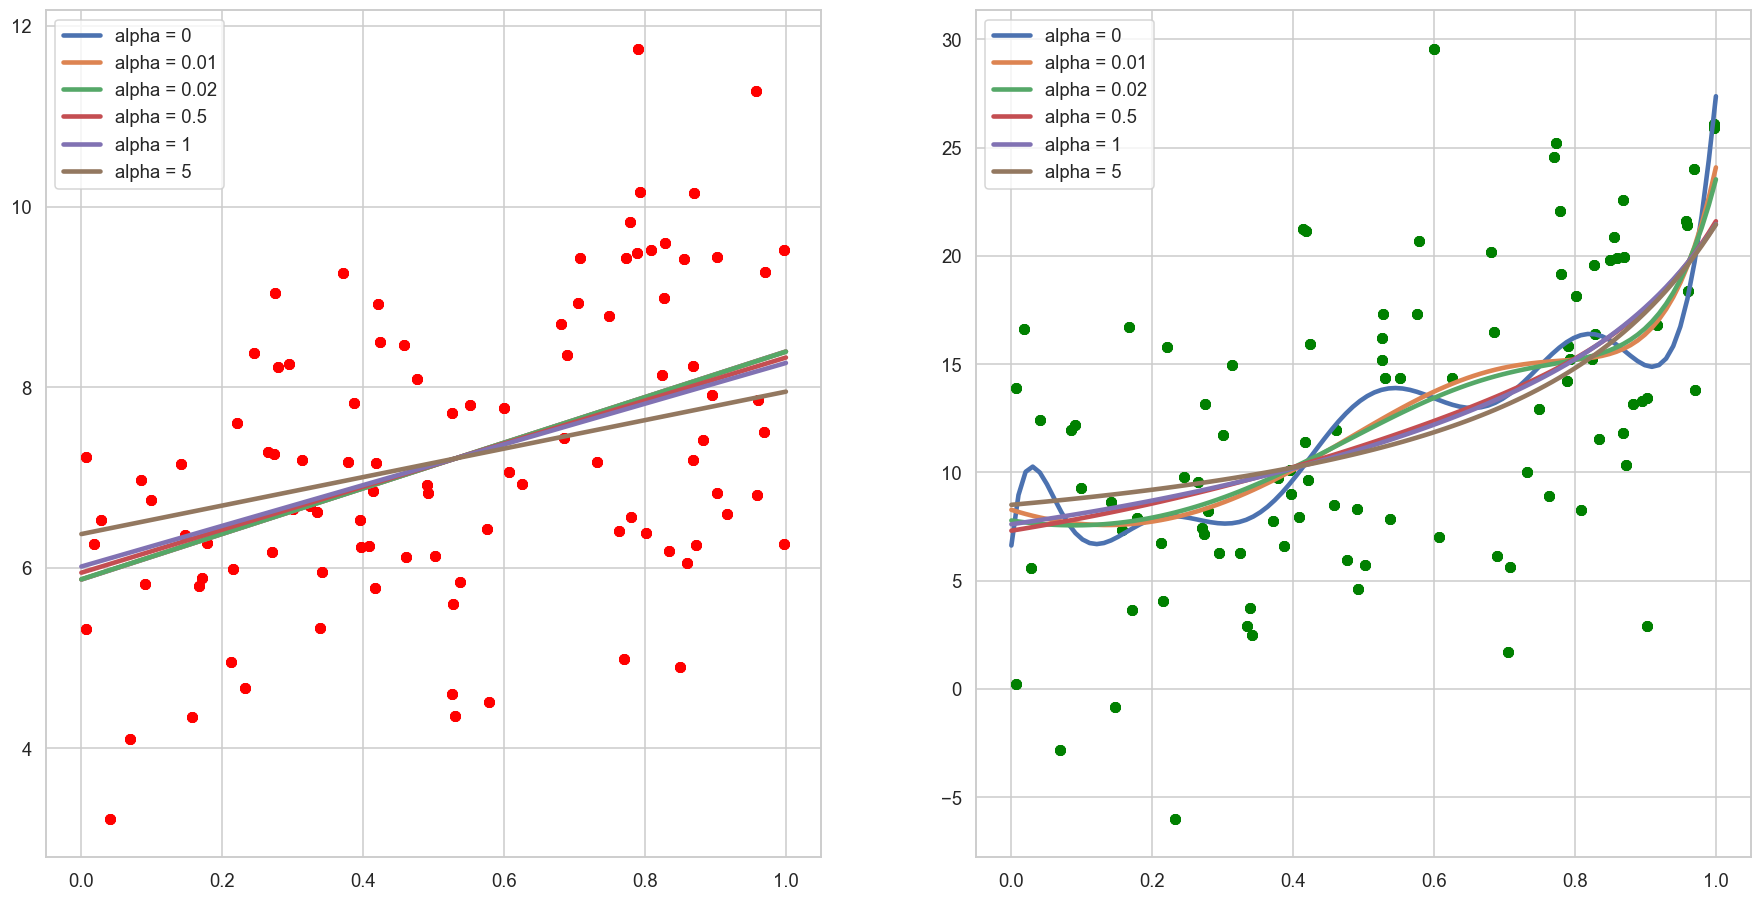

In [17]:
x_plot = np.linspace(0 , 1 , 100)
y_ridge_predict = ridge_reg.predict(x_plot.reshape([-1,1]))
m = 100
X_new = np.random.rand( m, 1)
y_new = 2 * X_new + 6 + np.random.randn(m , 1) * 1.5
y_ridge_poly = 10 * X_new**2 + 5*X_new + 5 + np.random.randn(m , 1) * 6
# plt.scatter(X_new, y_new)
# plt.plot(x_plot , y_ridge_predict , "r-" ,linewidth = 3 )
# plt.axhline(np.mean(y_new) ,  linewidth = 3 , color = "black" , linestyle = ":" , label = "y_mean")

alpha_list = [ 0 , 0.01 , 0.02 , 0.5 , 1 , 5]

for i in alpha_list :
    n = 10
    feat_expansion = PolynomialFeatures(degree = n , include_bias = False)
    ridge_reg_lin = Ridge(alpha = i , solver = "cholesky")
    ridge_reg_lin.fit(X_new , y_new.ravel())
    y_ridge_predict = ridge_reg_lin.predict(x_plot.reshape([-1,1]))
    
    X_ridge_poly = feat_expansion.fit_transform(X_new)
    x_plot_poly = feat_expansion.fit_transform(x_plot.reshape([-1, 1]))
    
    ridge_reg_poly = Ridge(alpha = i , solver = "cholesky" )
    ridge_reg_poly.fit( X_ridge_poly  , y_ridge_poly.ravel() )
    y_ridge_poly_predict = ridge_reg_poly.predict(x_plot_poly) 
    
    
    
    plt.subplot(121) ; plt.plot(x_plot , y_ridge_predict , linewidth = 3 , label = f"alpha = {i}") , plt.scatter(X_new, y_new , color = "red")
    plt.legend()
    plt.subplot(122) ; plt.plot(x_plot , y_ridge_poly_predict , linewidth = 3 , label = f"alpha = {i}") , plt.scatter(X_new, y_ridge_poly , color = "green")
    plt.legend()

In [18]:

def gradient_path(Theta , X ,y , eta , l1 , l2 , core = 1, steps = 200 ):
    path = [Theta]
    
    for i in range(steps):
        
        gradient = core *  2 / len(X) * X.T @ (X @ Theta - y ) + l1 * np.sign(Theta) + l2 * 2 * Theta
        Theta = Theta - eta * gradient
        path.append(Theta)
    return np.array(path)



def cost_fxn_plot(X ,y  , l1 , l2 , n= 1000 , lim_neg = -2 , lim_pos = 4):
    
    t1 , t2     =   np.linspace(lim_neg , lim_pos , n) , np.linspace(lim_neg , lim_pos , n) 
    T1 ,T2      =   np.meshgrid(t1 , t2) # ---> use this to create the lattice points 
    stacked_arr =   np.stack((T1.ravel() , T2.ravel()) ,axis = 1) # ---> stacked along axis 1 shape = (n**2 , 2)
    Theta       =   np.array(stacked_arr).reshape((n**2 , 2 , 1)) # ---> creating a 3d array so that each element act as a (2,1) array
    JR          =   np.mean((np.array([X] * n ** 2) @ Theta  - np.array([y] * n ** 2))**2 , axis= 1) + l1 * np.linalg.norm(Theta , axis = 1 , ord = 1) + l2 * np.linalg.norm(Theta , ord = 2 , axis = 1)
    return T1 ,T2 ,JR.reshape((n , n))

<Figure size 1100x1100 with 0 Axes>

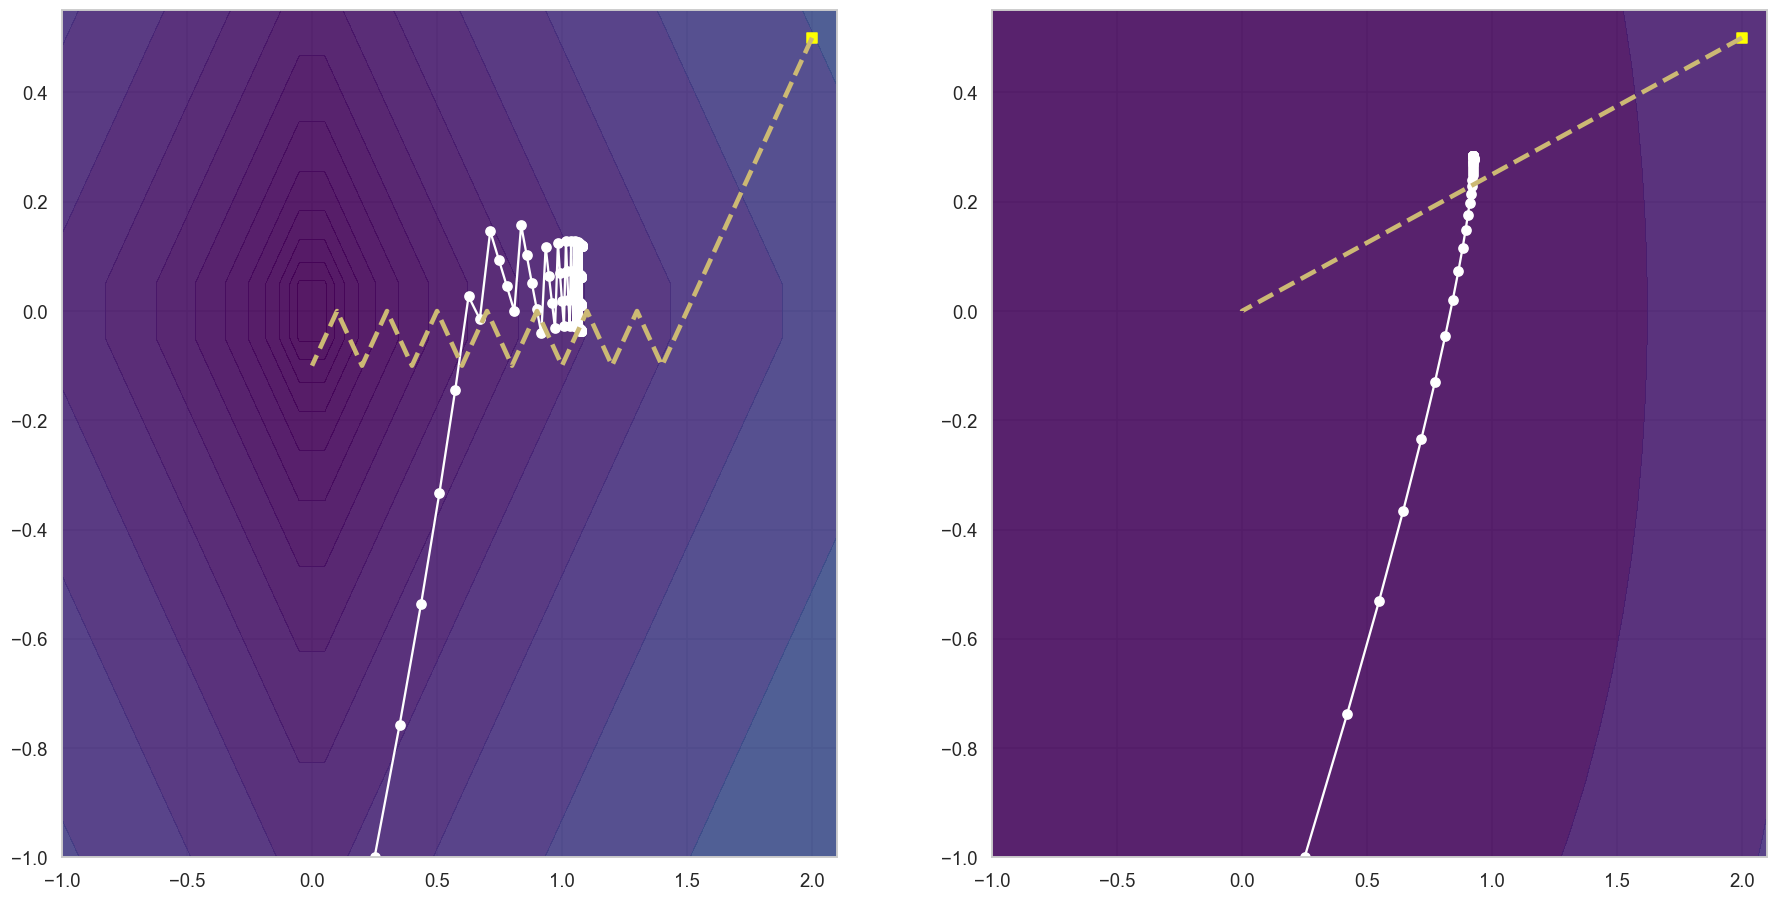

In [19]:

t1 ,t2 = np.linspace(-5 ,5 , 100) , np.linspace(-5 , 5 , 100)

T1 , T2 = np.meshgrid(t1 ,t2)

levels_l = np.exp(np.linspace(-2.5, 2.5 , 20)) 
levels_r = (np.linspace(0 , 50 , 20) ) 

Zl = np.abs(T1) + np.abs(T2)

Zr = T1**2 + T2**2

plt.figure(figsize = (10,10))

fig , axes  = plt.subplots(nrows = 1  ,ncols= 2 , figsize = (20 , 10)) 

axes[0].contourf(T1 ,T2 , Zl  ,cmap ="viridis" , levels = levels_l , alpha = 0.9)
axes[1].contourf(T1 ,T2 , Zr  ,cmap ="viridis" , levels = levels_r  ,alpha = 0.9)

t_init = np.array([[0.25] , [-1]])
theta0 = np.array([[2] , [0.5]])

Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

penalty_l = gradient_path(theta0 , Xr ,yr ,eta = 0.05 , l1 = 2 , l2 = 0 , core = 0  )
penalty_r = gradient_path(theta0 , Xr ,yr,eta = 0.05  , l1 = 0, l2 = 2, core = 0)
cost_l    = gradient_path(t_init , Xr ,yr , eta = 0.05 , l1 = 2 , l2 = 0 , core = 1 )  
cost_r    = gradient_path(t_init , Xr ,yr , eta = 0.05 , l1 = 0 , l2 = 1.2 , core = 1 )  

axes[0].plot(cost_l[: , 0] , cost_l[: ,1] , "w-o"  )
axes[0].plot(penalty_l[: ,0] , penalty_l[: , 1] , "y--" , linewidth = 3)
axes[0].scatter(theta0[0] , theta0[1] , marker = "s" , color = "yellow")
axes[0].set_ylim(-1 , 0.55)
axes[0].set_xlim(-1 ,2.1)


axes[1].plot(cost_r[: ,0] , cost_r[:, 1 ] , "w-o")
axes[1].scatter(theta0[0] , theta0[1] , marker = "s" , color = "yellow")
axes[1].plot(penalty_r[: ,0] , penalty_r[: , 1] , "y--" , linewidth = 3)
axes[1].set_ylim(-1 , 0.55)
axes[1].set_xlim(-1 ,2.1)
 
plt.show()
 

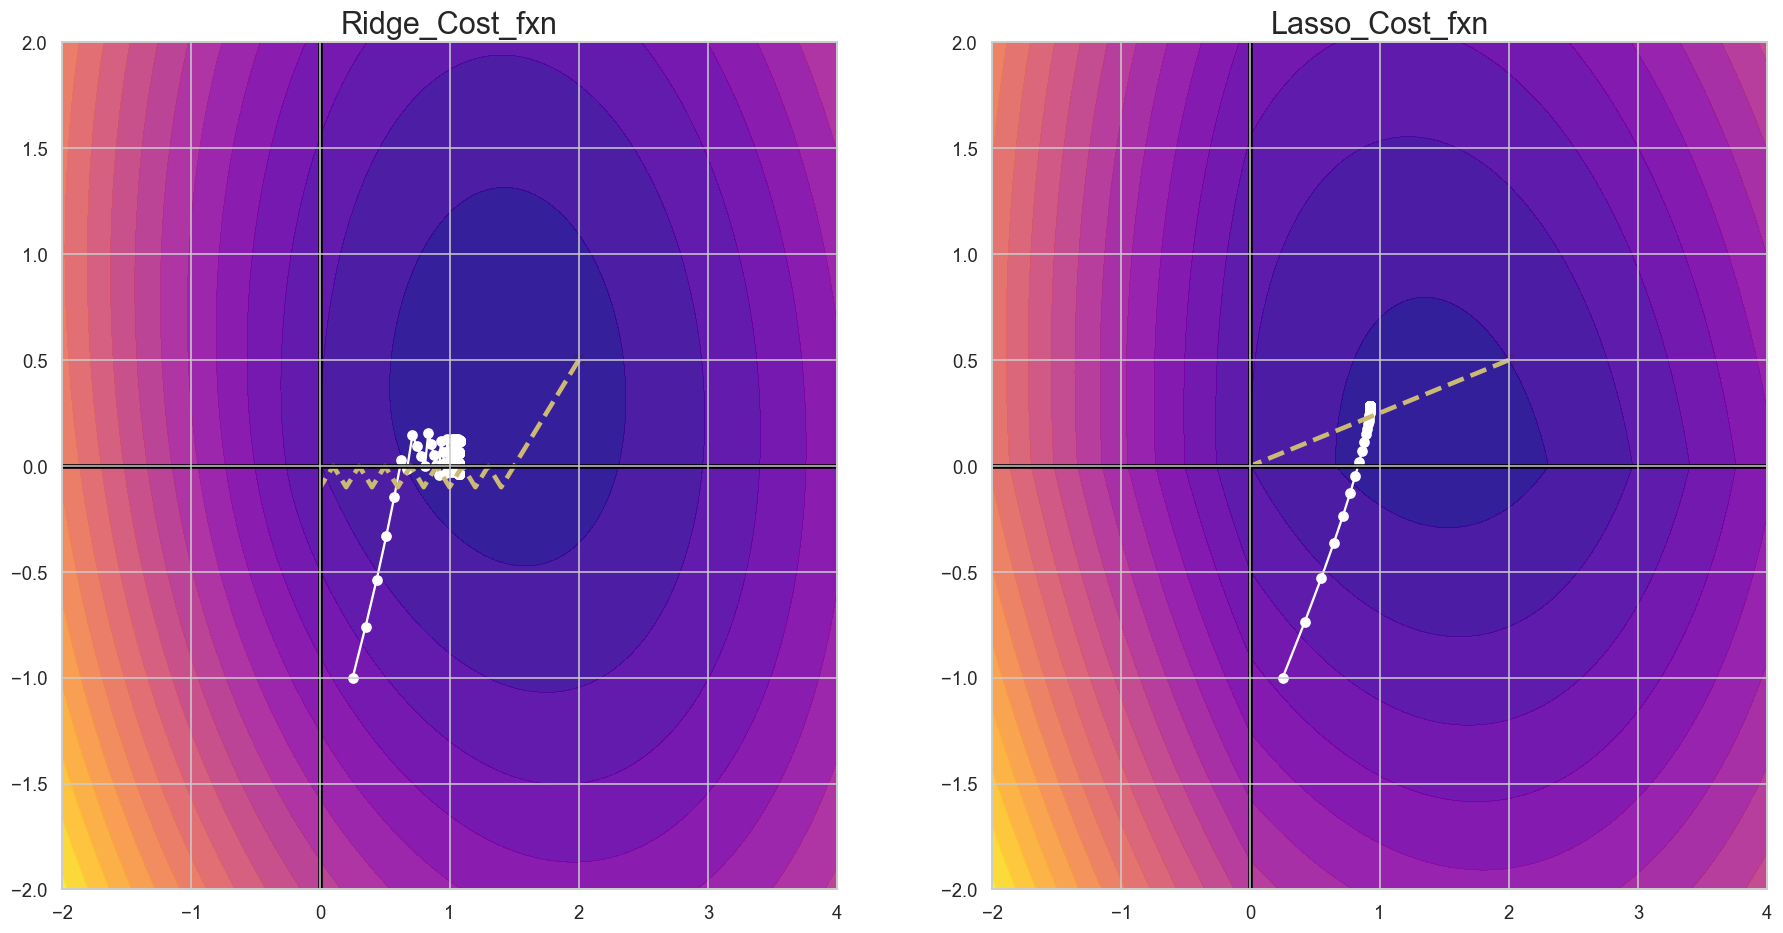

In [20]:

X_ridge , Y_ridge ,Z_ridge  = cost_fxn_plot(Xr ,yr , n =1000 ,l1 = 0 ,
                                            l2 = 1.2 , lim_neg=-2 ,lim_pos = 4 )
X_lasso , Y_lasso ,Z_lasso  = cost_fxn_plot(Xr ,yr , n =1000 ,l1 = 1.2 , 
                                            l2 = 0 , lim_neg=-2 ,lim_pos = 4 )

fig , axes = plt.subplots(nrows = 1 , ncols = 2  , figsize = (20 , 10 ))


axes[0].plot(cost_l[: , 0] , cost_l[: ,1] , "w-o"  )
axes[0].plot(penalty_l[: ,0] , penalty_l[: , 1] , "y--" , linewidth = 3)
axes[0].scatter(theta0[0] , theta0[1] , marker = "s" , color = "yellow")
axes[0].set_ylim(-2 , 2)
axes[0].set_xlim(-2 ,4)
axes[0].contourf(X_ridge, Y_ridge, Z_ridge, levels=20, cmap='plasma' , alpha = 0.9)
axes[0].set_axisbelow(False) # ---> brings the grid above 
axes[0].axvline(x=0, color='black', linewidth=3)   
axes[0].axhline(y=0, color='black', linewidth=3)
axes[0].set_title("Ridge_Cost_fxn")

axes[1].plot(cost_r[: ,0] , cost_r[:, 1 ] , "w-o")
axes[1].scatter(theta0[0] , theta0[1] , marker = "s" , color = "yellow")
axes[1].plot(penalty_r[: ,0] , penalty_r[: , 1] , "y--" , linewidth = 3)
axes[1].set_ylim(-2 , 2)
axes[1].set_xlim(-2 ,4)
axes[1].contourf(X_lasso, Y_lasso, Z_lasso, levels=20, cmap='plasma' , alpha = 0.9)
axes[1].set_axisbelow(False)
axes[1].axvline(x=0, color='black', linewidth=3)   
axes[1].axhline(y=0, color='black', linewidth=3)
axes[1].set_title("Lasso_Cost_fxn")

plt.show()
